# shows basic summaries, and plots a distribution.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
bird_df = pd.read_csv('csv/birds.csv', low_memory=False)
print('Loaded dataset with shape:', bird_df.shape)
bird_df.head()

Loaded dataset with shape: (49019, 26)


,bird_observation_id,record_id,species_common_name,species_scientific_name,species_abbreviation,age,wan_plumage_phase,plumage_phase,sex,count,...,sitting_on_ship,in_hand,n_flying_past,flying_past,n_accompanying,accompanying,n_following_ship,following_ship,moulting,naturally_feeding
0,1,1083001,Royal / Wandering albatross,Diomedea epomophora / sanfordi / antipodensis ...,DIOEPOSANANTEXU,NaN,NaN,NaN,NaN,6.0,...,False,False,0.0,False,6.0,True,0.0,False,NaN,False
1,2,1083001,Black-browed albatross sensu lato,Diomedea impavida / melanophrys,DIOIMPMEL,NaN,NaN,NaN,NaN,2.0,...,False,False,0.0,False,2.0,True,0.0,False,NaN,False
2,3,1083001,Cape petrel,Daption capense,DAPCAP,NaN,NaN,NaN,NaN,8.0,...,False,False,0.0,False,8.0,True,0.0,False,NaN,False
3,4,1083001,Fairy prion,Pachyptila turtur,PACTUR,NaN,NaN,NaN,NaN,2.0,...,False,False,0.0,False,2.0,True,0.0,False,NaN,False
4,5,1083001,Sooty shearwater,Puffinus griseus,PUFGRI,NaN,NaN,NaN,NaN,4.0,...,False,False,0.0,False,4.0,True,0.0,False,NaN,False


In [3]:
# Basic information and descriptive statistics
bird_df.info()
bird_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49019 entries, 0 to 49018
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bird_observation_id      49019 non-null  int64  
 1   record_id                49019 non-null  int64  
 2   species_common_name      48328 non-null  object 
 3   species_scientific_name  47918 non-null  object 
 4   species_abbreviation     48328 non-null  object 
 5   age                      10182 non-null  object 
 6   wan_plumage_phase        9575 non-null   object 
 7   plumage_phase            81 non-null     object 
 8   sex                      4 non-null      object 
 9   count                    46320 non-null  float64
 10  n_feeding                22571 non-null  float64
 11  feeding                  27924 non-null  object 
 12  n_sitting_on_water       22571 non-null  float64
 13  sitting_on_water         27897 non-null  object 
 14  n_sitting_on_ice      

,bird_observation_id,record_id,count,n_feeding,n_sitting_on_water,n_sitting_on_ice,n_flying_past,n_accompanying,n_following_ship
count,49019.00000,4.901900e+04,46320.000000,22571.000000,22571.000000,22571.000000,22571.000000,22571.000000,22571.000000
mean,24510.00000,3.956808e+07,41.930332,11.309379,4.129635,0.024855,23.605733,0.339595,0.995791
std,14150.71076,3.593714e+07,1283.408411,744.113665,164.367815,2.095558,1195.523446,7.494219,2.415947
min,1.00000,1.083001e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12255.50000,6.059010e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,24510.00000,1.300400e+07,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,36764.50000,8.401602e+07,4.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,49019.00000,8.800704e+07,99999.000000,99999.000000,20000.000000,300.000000,99999.000000,1000.000000,50.000000


In [4]:
# Check for missing values
bird_df.isnull().sum()

bird_observation_id            0
record_id                      0
species_common_name          691
species_scientific_name     1101
species_abbreviation         691
age                        38837
wan_plumage_phase          39444
plumage_phase              48938
sex                        49015
count                       2699
n_feeding                  26448
feeding                    21095
n_sitting_on_water         26448
sitting_on_water           21122
n_sitting_on_ice           26448
sitting_on_ice             21131
sitting_on_ship            21132
in_hand                    21133
n_flying_past              26448
flying_past                21128
n_accompanying             26448
accompanying               21133
n_following_ship           26448
following_ship             21132
moulting                   48906
naturally_feeding          21170
dtype: int64

In [5]:
# Show available columns to pick a plotting column
bird_df.columns

Index(['bird_observation_id', 'record_id', 'species_common_name',
       'species_scientific_name', 'species_abbreviation', 'age',
       'wan_plumage_phase', 'plumage_phase', 'sex', 'count', 'n_feeding',
       'feeding', 'n_sitting_on_water', 'sitting_on_water', 'n_sitting_on_ice',
       'sitting_on_ice', 'sitting_on_ship', 'in_hand', 'n_flying_past',
       'flying_past', 'n_accompanying', 'accompanying', 'n_following_ship',
       'following_ship', 'moulting', 'naturally_feeding'],
      dtype='object')

In [6]:
# Load the dataset
ship_df = pd.read_csv('csv/ships.csv')
print('Loaded dataset with shape:', ship_df.shape)
ship_df.head()

Loaded dataset with shape: (12310, 21)


,record_id,date,time,latitude,longitude,hemisphere,activity,speed,direction,cloud_cover,...,wind_speed_class,wind_direction,air_temperature,pressure,sea_state_class,sea_surface_temperature,depth,observer,census_method,season
0,1083001,1975-10-15,14:00:00,-45.917,165.400,E,"steaming, sailing",15.0,NaN,overcast,...,5.0,NaN,NaN,NaN,5.0,NaN,NaN,D. Jeffcock,full,spring
1,1084001,1975-11-03,13:10:00,-35.533,125.000,E,"steaming, sailing",14.0,NaN,partially cloudy,...,4.0,NaN,NaN,NaN,4.0,NaN,NaN,D. Jeffcock,full,spring
2,1084002,1975-11-04,14:20:00,-37.667,132.250,E,"steaming, sailing",14.5,NaN,overcast,...,4.0,NaN,NaN,NaN,4.0,NaN,NaN,D. Jeffcock,full,spring
3,1084003,1975-11-08,16:15:00,-40.000,162.000,E,"steaming, sailing",14.6,NaN,partially cloudy,...,4.0,NaN,NaN,NaN,4.0,NaN,NaN,D. Jeffcock,full,spring
4,1086001,1975-11-16,12:30:00,-36.167,174.917,E,"steaming, sailing",15.0,NaN,partially cloudy,...,0.0,NaN,NaN,NaN,1.0,NaN,NaN,D. Jeffcock,full,spring


In [7]:
ship_df.columns

Index(['record_id', 'date', 'time', 'latitude', 'longitude', 'hemisphere',
       'activity', 'speed', 'direction', 'cloud_cover', 'precipitation',
       'wind_speed_class', 'wind_direction', 'air_temperature', 'pressure',
       'sea_state_class', 'sea_surface_temperature', 'depth', 'observer',
       'census_method', 'season'],
      dtype='object')

In [8]:
ship_df.info()
ship_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12310 entries, 0 to 12309
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   record_id                12310 non-null  int64  
 1   date                     12310 non-null  object 
 2   time                     12308 non-null  object 
 3   latitude                 12300 non-null  float64
 4   longitude                12299 non-null  float64
 5   hemisphere               12299 non-null  object 
 6   activity                 12310 non-null  object 
 7   speed                    7832 non-null   float64
 8   direction                1255 non-null   float64
 9   cloud_cover              7523 non-null   object 
 10  precipitation            7507 non-null   object 
 11  wind_speed_class         7622 non-null   float64
 12  wind_direction           1292 non-null   float64
 13  air_temperature          1036 non-null   float64
 14  pressure              

,record_id,latitude,longitude,speed,direction,wind_speed_class,wind_direction,air_temperature,pressure,sea_state_class,sea_surface_temperature,depth
count,1.231000e+04,12300.000000,12299.000000,7832.000000,1255.000000,7622.000000,1292.000000,1036.000000,770.000000,7559.000000,685.000000,130.000000
mean,3.982013e+07,-39.220412,159.930302,12.711223,169.349004,3.732879,174.706656,15.284653,1014.842857,3.555761,14.719562,380.846154
std,3.620492e+07,5.887060,17.420331,5.181784,102.474477,1.828859,108.498083,3.828644,8.849117,1.095605,4.076573,352.048567
min,1.083001e+06,-69.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.500000,991.000000,1.000000,-1.000000,60.000000
25%,6.059008e+06,-40.600000,152.000000,10.500000,90.000000,2.000000,68.000000,13.400000,1010.000000,3.000000,12.800000,162.500000
50%,1.203000e+07,-38.267000,163.117000,14.500000,165.000000,4.000000,203.000000,15.500000,1016.000000,4.000000,15.100000,290.000000
75%,8.402601e+07,-35.500000,172.917000,16.000000,270.000000,5.000000,270.000000,17.800000,1021.000000,4.000000,17.000000,507.500000
max,8.800704e+07,-19.000000,179.983000,22.000000,358.000000,12.000000,350.000000,24.600000,1040.000000,6.000000,27.000000,2200.000000


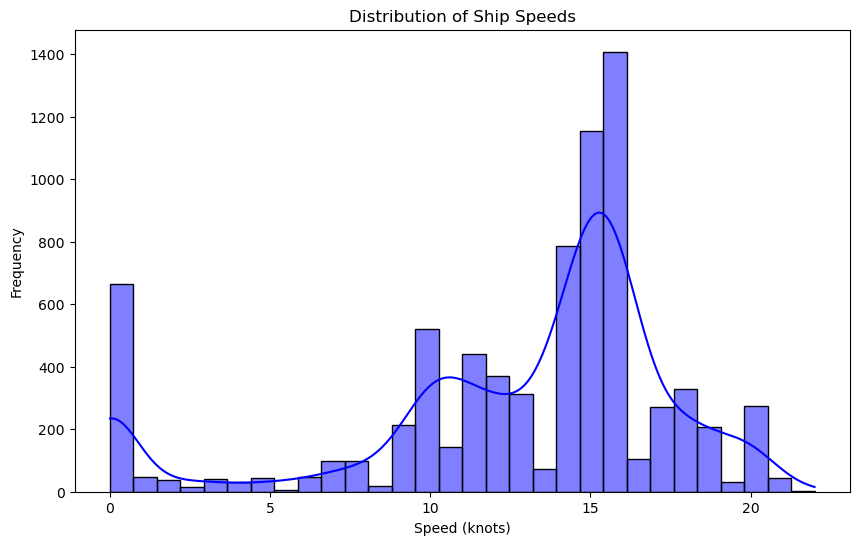

In [9]:
# Plotting the distribution of ship speeds
plt.figure(figsize=(10, 6))
sns.histplot(ship_df['speed'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of Ship Speeds')
plt.xlabel('Speed (knots)')
plt.ylabel('Frequency')
plt.show()

In [10]:
df = bird_df.merge(ship_df, on="record_id", how="left")

print("Joined shape:", df.shape)
print("Rows with no ship match:", df["latitude"].isna().sum())

df.sample(n = 20)

Joined shape: (49019, 46)
Rows with no ship match: 31


,bird_observation_id,record_id,species_common_name,species_scientific_name,species_abbreviation,age,wan_plumage_phase,plumage_phase,sex,count,...,wind_speed_class,wind_direction,air_temperature,pressure,sea_state_class,sea_surface_temperature,depth,observer,census_method,season
11011,11012,6034045,Wandering albatross sensu lato PL3,Diomedea antipodensis / exulans PL3,DIOANTEXU PL3,NaN,white patch on wing,NaN,NaN,1.0,...,4.0,NaN,NaN,NaN,4.0,NaN,NaN,J. Jenkins,full,winter
9342,9343,6007002,Red-billed gull SUBAD,Larus novaehollandiae SUBAD,LARNOV SUBAD,subadult,NaN,NaN,NaN,2.0,...,4.0,NaN,NaN,NaN,4.0,NaN,NaN,N. Cheshire,full,autumn
40358,40359,85032033,Little shearwater,Puffinus assimilis,PUFASS,NaN,NaN,NaN,NaN,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,J. Jenkins,full,summer
40281,40282,85032017,Black-browed albatross sensu lato SUBAD,Diomedea impavida / melanophrys SUBAD,DIOIMPMEL SUBAD,subadult,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,J. Jenkins,full,summer
39393,39394,85020002,Southern black-backed gull SUBAD,Larus dominicanus SUBAD,LARDOM SUBAD,subadult,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,J. Jenkins,full,spring
28351,28352,64023016,Black-browed albatross sensu lato SUBAD,Diomedea impavida / melanophrys SUBAD,DIOIMPMEL SUBAD,subadult,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,15.4,NaN,J. Jenkins,full,winter
32950,32951,67006088,Wandering albatross sensu lato PL3,Diomedea antipodensis / exulans PL3,DIOANTEXU PL3,NaN,white patch on wing,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,J. Jenkins,full,autumn
1151,1152,2005009,Mottled petrel,Pterodroma inexpectata,PTEINE,NaN,NaN,NaN,NaN,2.0,...,5.0,NaN,NaN,NaN,4.0,NaN,NaN,J. Jenkins,full,summer
30078,30079,65001057,Wandering albatross sensu lato PL2,Diomedea antipodensis / exulans PL2,DIOANTEXU PL2,NaN,brown plumage breaking,NaN,NaN,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,J. Jenkins,full,summer
23697,23698,12017003,Masked booby AD,Sula dactylatra AD,SULDAC AD,adult,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,3.0,NaN,NaN,M.J. Carter,full,autumn


In [11]:
# How often is species_common_name actually populated vs NA?
print("Bird records total:", len(bird_df))
print("No birds recorded (NA common name):", bird_df["species_common_name"].isna().sum())
print("Actual sightings:", bird_df["species_common_name"].notna().sum())
            
# How often is scientific name missing when common name is present?
sightings = bird_df[bird_df["species_common_name"].notna()]
print("\nMissing scientific name:", sightings["species_scientific_name"].isna().sum())
print("Missing age:", sightings["age"].isna().sum())
print("Missing sex:", sightings["sex"].isna().sum())

Bird records total: 49019
No birds recorded (NA common name): 691
Actual sightings: 48328

Missing scientific name: 410
Missing age: 38146
Missing sex: 48324


In [12]:
# Date range of the dataset
ship_df["date"] = pd.to_datetime(ship_df["date"])
print("Date range:", ship_df["date"].min(), "to", ship_df["date"].max())

# How many unique species?
print("Unique common names:", bird_df["species_common_name"].nunique())
print("Unique scientific names:", bird_df["species_scientific_name"].nunique())

# Top 10 most-seen species
top_species = (
    bird_df[bird_df["species_common_name"].notna()]
    ["species_common_name"]
    .value_counts()
    .head(10)
)
print(top_species)

Date range: 1969-07-31 00:00:00 to 1990-12-21 00:00:00
Unique common names: 321
Unique scientific names: 310
species_common_name
Wandering albatross sensu lato PL2      3104
Cape petrel                             2936
Wandering albatross sensu lato PL3      2885
Grey-faced petrel                       2597
Prion (unidentified)                    2094
Giant petrel sensu lato                 2094
Wandering albatross sensu lato PL1      1818
Black-browed albatross sensu lato AD    1805
Wandering albatross sensu lato PL4      1475
Australasian gannet AD                  1366
Name: count, dtype: int64


In [13]:
# How many distinct scientific names does each common name map to?
# If a common name maps to 2+ scientific names, something is inconsistent
name_map = (
    sightings
    .groupby("species_common_name")["species_scientific_name"]
    .nunique()
    .reset_index()
    .rename(columns={"species_scientific_name": "n_scientific_names"})
    .sort_values("n_scientific_names", ascending=False)
)

print("Common names that map to more than one scientific name:")
print(name_map[name_map["n_scientific_names"] > 1].head(20))

Common names that map to more than one scientific name:
Empty DataFrame
Columns: [species_common_name, n_scientific_names]
Index: []


In [14]:
# The wandering albatross entries encode plumage in the common name (PL1, PL2, etc.)
# Check: does the wan_plumage_phase column actually capture this?
wan = sightings[sightings["species_common_name"].str.contains("Wandering", na=False)]

print("Wandering albatross entries:", len(wan))
print("\nCommon name variants:")
print(wan["species_common_name"].value_counts().head(15))

print("\nwan_plumage_phase filled:")
print(wan["wan_plumage_phase"].value_counts(dropna=False))

Wandering albatross entries: 11296

Common name variants:
species_common_name
Wandering albatross sensu lato PL2      3104
Wandering albatross sensu lato PL3      2885
Wandering albatross sensu lato PL1      1818
Wandering albatross sensu lato PL4      1475
Wandering albatross sensu lato AD        772
Wandering albatross sensu lato SUBAD     413
Wandering albatross sensu lato PL5       278
Wandering albatross sensu lato           277
Wandering albatross sensu lato JUV       253
Wandering albatross sensu lato IMM        18
Royal / Wandering albatross                3
Name: count, dtype: int64

wan_plumage_phase filled:
wan_plumage_phase
brown plumage breaking    3104
white patch on wing       2886
all brown                 1818
NaN                       1735
wing patch breaking       1475
white                      278
Name: count, dtype: int64


In [15]:
# Some common names include " AD" (adult), " JUV" (juvenile) etc.
# Check whether the age column captures these

has_age_in_name = sightings[
    sightings["species_common_name"].str.contains(r"\bAD\b|\bJUV\b|\bIMM\b|\bSUBAD\b", na=False, regex=True)
]

print("Entries with age in common name:", len(has_age_in_name))
print("Of those, age column is NaN:", has_age_in_name["age"].isna().sum())
print("Of those, age column is filled:", has_age_in_name["age"].notna().sum())

# Show examples where age is in the name but NOT in the column
age_mismatch = has_age_in_name[has_age_in_name["age"].isna()]
print("\nSample mismatches:")
print(age_mismatch[["species_common_name", "age"]].head(10))

Entries with age in common name: 10177
Of those, age column is NaN: 0
Of those, age column is filled: 10177

Sample mismatches:
Empty DataFrame
Columns: [species_common_name, age]
Index: []


In [16]:
# Same check for sex — "M" or "F" in the name
has_sex_in_name = sightings[
    sightings["species_common_name"].str.contains(r"\bMALE\b|\bFEMALE\b|\b\sM\b|\b\sF\b", na=False, regex=True, case=False)
]

print("Entries with sex in common name:", len(has_sex_in_name))
print("Of those, sex column filled:", has_sex_in_name["sex"].notna().sum())
print("Of those, sex column NaN:", has_sex_in_name["sex"].isna().sum())

Entries with sex in common name: 1
Of those, sex column filled: 1
Of those, sex column NaN: 0


In [17]:
# Strip trailing age/plumage suffixes to get a clean base species name
sightings = sightings.copy()
sightings["base_species"] = (
    sightings["species_common_name"]
    .str.replace(r"\s+(PL\d|AD|JUV|IMM|SUBAD|sensu lato|sensu stricto).*$", "", regex=True)
    .str.strip()
)

top_base = sightings["base_species"].value_counts().head(15)
print(top_base)

base_species
Wandering albatross                                   11293
Black-browed albatross                                 3610
Cape petrel                                            2936
Grey-faced petrel                                      2597
Giant petrel                                           2168
Prion (unidentified)                                   2094
Australasian gannet                                    1679
Shy / white-capped / Salvin's /  Chatham mollymawk     1541
Southern black-backed gull                             1540
Sooty shearwater                                       1364
Buller's shearwater                                    1306
Short-tailed shearwater                                 924
Flesh-footed shearwater                                 849
Red-billed gull                                         756
Yellow-nosed mollymawk                                  684
Name: count, dtype: int64


In [19]:
# What were birds doing? (as % of sightings)
behaviour_cols = ["feeding", "sitting_on_water", "sitting_on_ice",
                  "sitting_on_ship", "flying_past", "accompanying",
                  "following_ship", "naturally_feeding"]

# Convert non-numeric values to numeric (True/False or 1/0)
# This handles common text representations like 'Yes'/'No', 'True'/'False', etc.
behaviour_numeric = sightings[behaviour_cols].apply(lambda x: pd.to_numeric(x, errors='coerce'))

# Alternative approach if data contains 'Yes'/'No' strings:
# behaviour_numeric = sightings[behaviour_cols].replace({'Yes': 1, 'No': 0})

behaviour_pct = (
    behaviour_numeric
    .mean() * 100
).round(1).sort_values(ascending=False)

print("% of sightings where behaviour was observed:")
print(behaviour_pct)

% of sightings where behaviour was observed:
following_ship       42.4
flying_past          42.0
accompanying         23.9
feeding              12.9
sitting_on_water     12.4
naturally_feeding     3.5
sitting_on_ship       0.3
sitting_on_ice        0.1
dtype: float64


In [20]:
# Ships attracted birds — which species followed most?
followers = (
    sightings[sightings["following_ship"] == True]
    ["base_species"]
    .value_counts()
    .head(10)
)
print("Top ship-following species:")
print(followers)

Top ship-following species:
base_species
Wandering albatross               6066
Black-browed albatross            1599
Cape petrel                       1021
Giant petrel                       530
White-chinned petrel               245
Red-billed gull                    193
Northern giant petrel              165
Flesh-footed shearwater            159
All dark petrel (unidentified)     123
Grey-faced petrel                  123
Name: count, dtype: int64


In [22]:
#Count distribution (how many birds per sighting?)
# Filter out the sentinel value 99999
real_counts = sightings[sightings["count"] < 99999]["count"]

print("Count stats:")
print(real_counts.describe())
print(f"\nSightings of 1 bird: {(real_counts == 1).sum()}")
print(f"Sightings of 10+ birds: {(real_counts >= 10).sum()}")
print(f"Sightings of 100+ birds: {(real_counts >= 100).sum()}")

Count stats:
count    46314.000000
mean        28.980848
std        593.938037
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max      50000.000000
Name: count, dtype: float64

Sightings of 1 bird: 20357
Sightings of 10+ birds: 5295
Sightings of 100+ birds: 1018


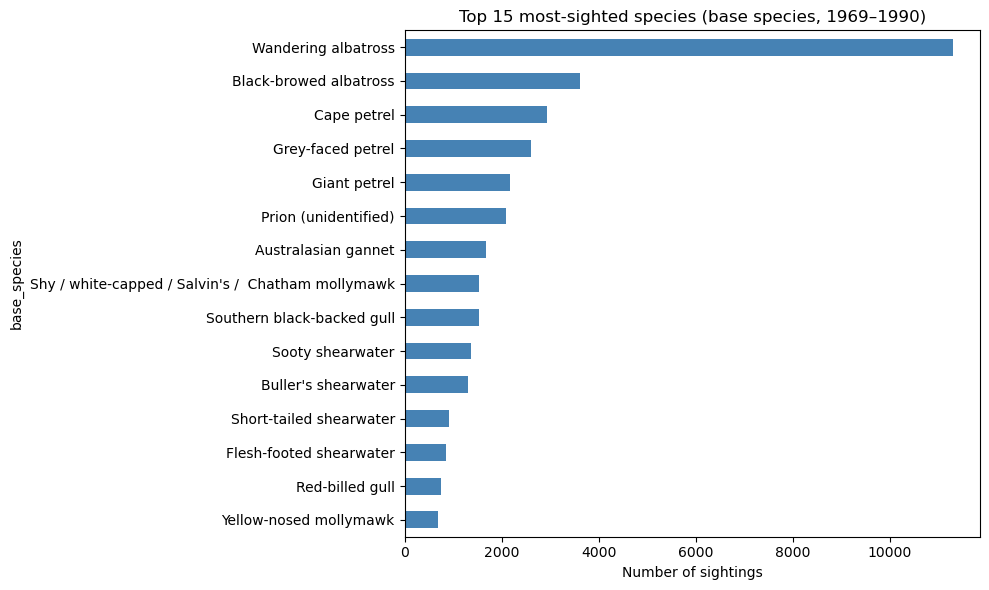

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
top_base.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of sightings")
ax.set_title("Top 15 most-sighted species (base species, 1969–1990)")
plt.tight_layout()
plt.show()

In [33]:
# Load the lookup tables
beaufort = pd.read_csv("datasets/beaufort_scale.csv")
sea_states = pd.read_csv("datasets/sea_states.csv")

#sea_states.describe()
#beaufort.describe()

In [35]:
# Use the joined df (birds + ships) — filter out no-ship-match rows and sentinel counts
env = df[df["latitude"].notna() & (df["count"] < 99999)].copy()

wind_counts = (
    env.groupby("wind_speed_class")["count"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "total_birds", "mean": "avg_per_sighting", "count": "n_sightings"})
    .reset_index()
    .merge(beaufort[["wind_speed_class", "wind_description"]], on="wind_speed_class", how="left")
)

wind_counts

,wind_speed_class,total_birds,avg_per_sighting,n_sightings,wind_description
0,0.0,57240.0,88.881988,644,calm
1,1.0,129324.0,67.076763,1928,light air
2,2.0,109483.0,23.264556,4706,light breeze
3,3.0,202752.0,37.498058,5407,gentle breeze
4,4.0,96353.0,15.674801,6147,moderate breeze
5,5.0,61228.0,13.606222,4500,fresh breeze
6,6.0,84271.0,29.819887,2826,strong breeze
7,7.0,41665.0,26.640026,1564,near gale
8,8.0,12008.0,14.590522,823,gale
9,9.0,2531.0,17.455172,145,strong gale


In [36]:
sea_counts = (
    env.groupby("sea_state_class")["count"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "total_birds", "mean": "avg_per_sighting", "count": "n_sightings"})
    .reset_index()
    .merge(sea_states[["sea_state_class", "sea_state_description"]], on="sea_state_class", how="left")
)
sea_counts

,sea_state_class,total_birds,avg_per_sighting,n_sightings,sea_state_description
0,1.0,116018.0,59.132518,1962,"calm, rippled"
1,2.0,25.0,8.333333,3,smooth
2,3.0,411314.0,37.494439,10970,slight
3,4.0,184149.0,18.879332,9754,moderate
4,5.0,73327.0,15.333961,4782,rough
5,6.0,5990.0,6.670379,898,very rough


In [38]:
# Does what the ship is doing affect how many birds show up?
activity_summary = (
    env.groupby("activity")
    .agg(
        n_sightings=("count", "count"),
        avg_birds=("count", "mean"),
        pct_following=("following_ship", lambda x: x.eq(True).mean() * 100)
    )
    .round(1)
    .sort_values("avg_birds", ascending=False)
)
activity_summary

,n_sightings,avg_birds,pct_following
activity,,,
trawling,272,146.0,7.0
"steaming, sailing",42196,29.6,27.2
stationary,3153,15.4,0.5
oceanography,313,7.1,0.3
flying helicopters,2,6.0,0.0
line fishing,312,2.0,3.2
potting,38,1.7,0.0


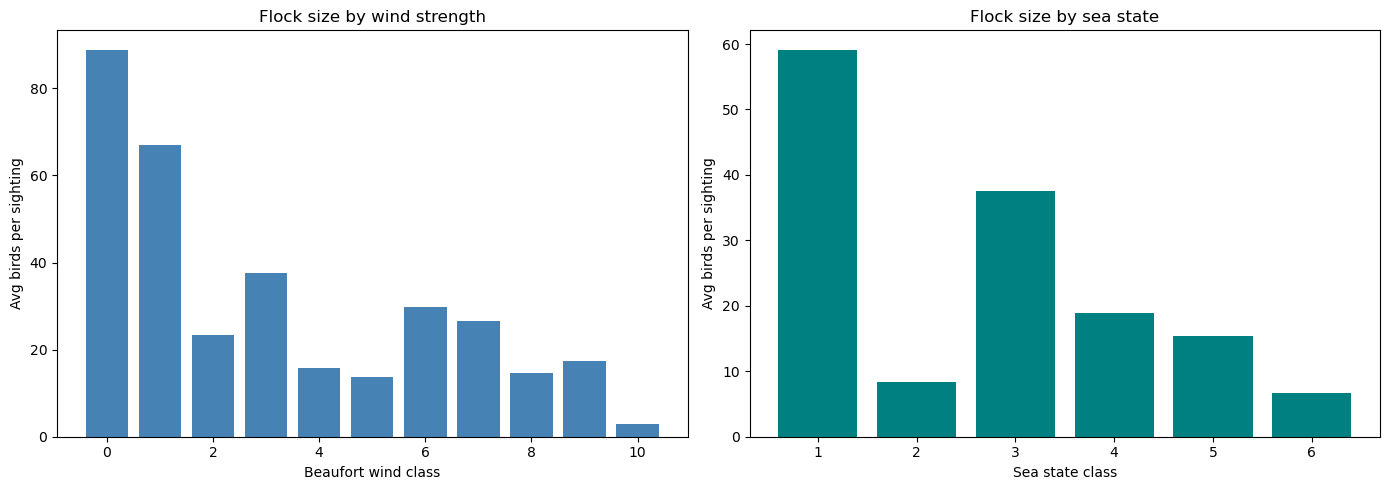

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average flock size by wind class
valid_wind = wind_counts[wind_counts["wind_speed_class"] <= 10]
axes[0].bar(valid_wind["wind_speed_class"], valid_wind["avg_per_sighting"], color="steelblue")
axes[0].set_xlabel("Beaufort wind class")
axes[0].set_ylabel("Avg birds per sighting")
axes[0].set_title("Flock size by wind strength")

# Right: average flock size by sea state
axes[1].bar(sea_counts["sea_state_class"], sea_counts["avg_per_sighting"], color="teal")
axes[1].set_xlabel("Sea state class")
axes[1].set_ylabel("Avg birds per sighting")
axes[1].set_title("Flock size by sea state")

plt.tight_layout()
plt.show()

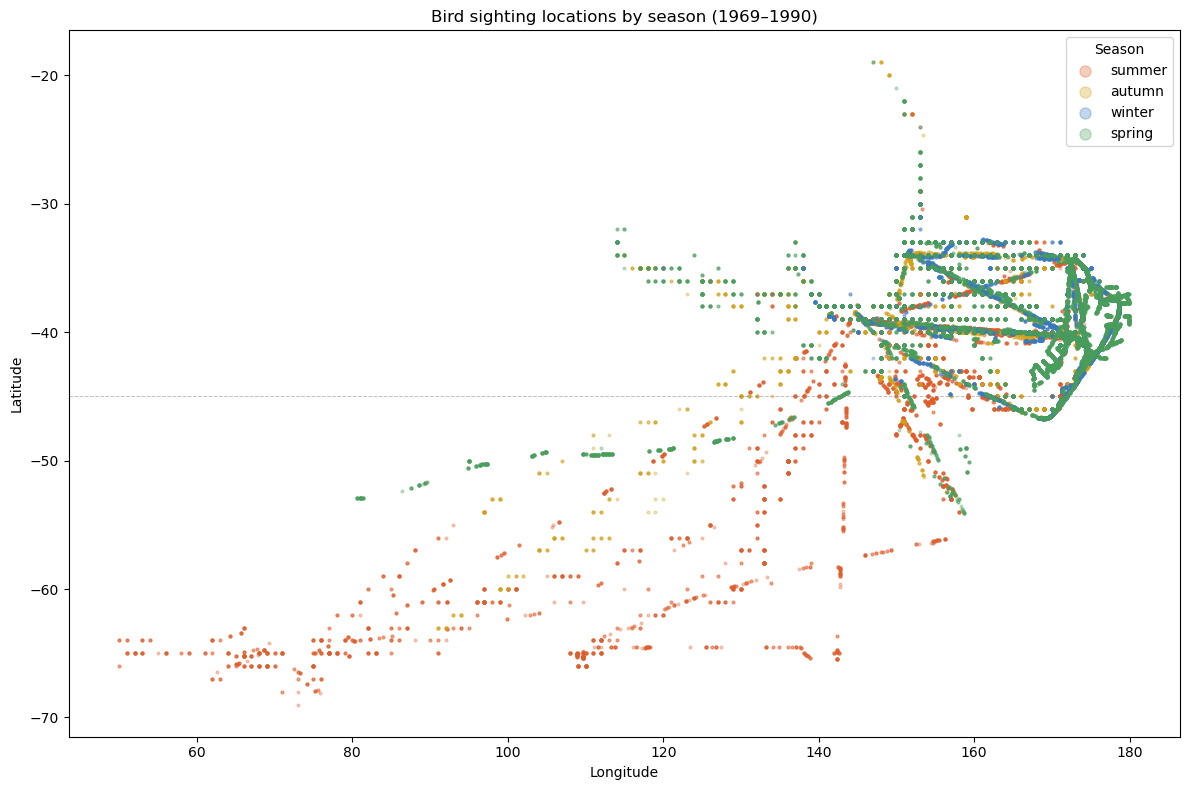

In [40]:
fig, ax = plt.subplots(figsize=(12, 8))

season_colours = {"summer": "#e05c2a", "autumn": "#d4a017", "winter": "#3a7abf", "spring": "#4a9e5c"}

for season, colour in season_colours.items():
    mask = df["season"] == season
    ax.scatter(
        df.loc[mask, "longitude"],
        df.loc[mask, "latitude"],
        c=colour, alpha=0.3, s=4, label=season
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bird sighting locations by season (1969–1990)")
ax.legend(markerscale=4, title="Season")
ax.axhline(-45, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)  # rough subantarctic line
plt.tight_layout()
plt.show()

In [49]:
# Fix: add base_species to the joined df too
df["base_species"] = (
    df["species_common_name"]
    .str.replace(r"\s+(PL\d|AD|JUV|IMM|SUBAD|sensu lato|sensu stricto).*$", "", regex=True)
    .str.strip()
)

top8 = df["base_species"].value_counts().head(8).index.tolist()

sea_by_species = (
    df[df["base_species"].isin(top8) & df["sea_state_class"].notna()]
    .groupby("base_species")["sea_state_class"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("Average sea state class by species (higher = rougher water):")
print(sea_by_species)

Average sea state class by species (higher = rougher water):
base_species
Prion (unidentified)                                  3.83
Grey-faced petrel                                     3.80
Black-browed albatross                                3.78
Wandering albatross                                   3.78
Cape petrel                                           3.76
Giant petrel                                          3.74
Shy / white-capped / Salvin's /  Chatham mollymawk    3.60
Australasian gannet                                   3.29
Name: sea_state_class, dtype: float64


In [47]:
df["year"] = pd.to_datetime(df["date"]).dt.year

yearly = (
    df[df["species_common_name"].notna()]
    .groupby("year")
    .agg(n_sightings=("bird_observation_id", "count"),
         n_ship_counts=("record_id", "nunique"))
    .reset_index()
)

yearly

,year,n_sightings,n_ship_counts
0,1969.0,1798,243
1,1975.0,817,196
2,1976.0,1515,363
3,1977.0,1262,284
4,1978.0,2813,714
5,1979.0,2653,687
6,1980.0,4411,999
7,1981.0,3839,1078
8,1982.0,3113,813
9,1983.0,1789,451


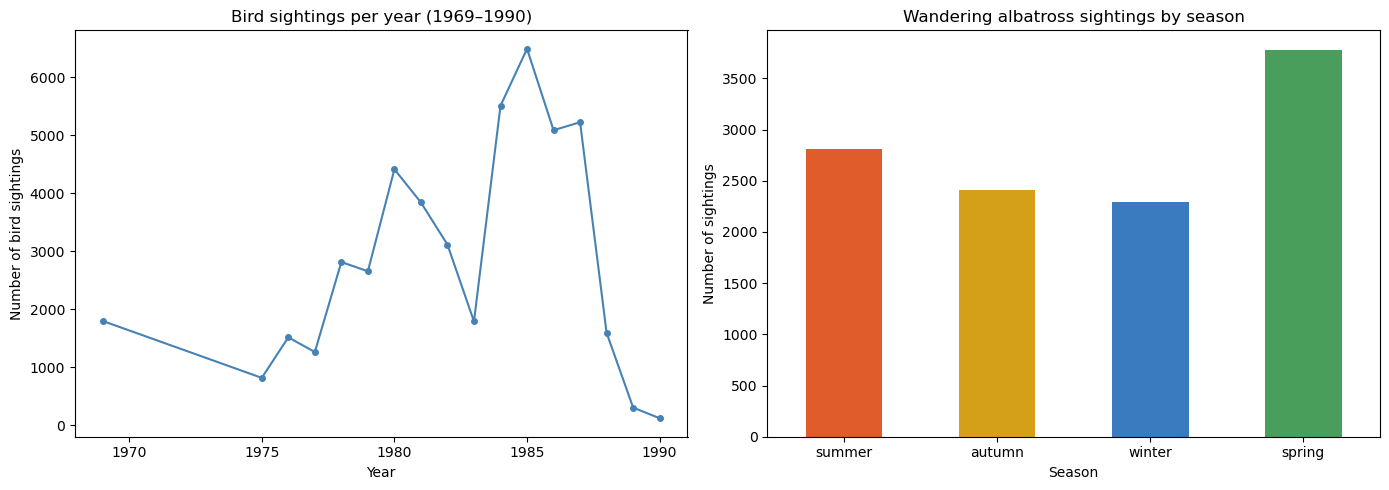

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sightings over time
axes[0].plot(yearly["year"], yearly["n_sightings"], marker="o", markersize=4, color="steelblue")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of bird sightings")
axes[0].set_title("Bird sightings per year (1969–1990)")

# Right: wandering albatross sightings by season
wan_season = (
    df[df["base_species"] == "Wandering albatross"]
    .groupby("season")
    .size()
    .reindex(["summer", "autumn", "winter", "spring"])
)
wan_season.plot(kind="bar", ax=axes[1], color=["#e05c2a", "#d4a017", "#3a7abf", "#4a9e5c"])
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Number of sightings")
axes[1].set_title("Wandering albatross sightings by season")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [53]:
top5 = df["base_species"].value_counts().head(5).index.tolist()

season_order = ["summer", "autumn", "winter", "spring"]
season_matrix = (
    df[df["base_species"].isin(top5)]
    .groupby(["base_species", "season"])
    .size()
    .unstack("season")
    .reindex(columns=season_order)
    .fillna(0)
    .astype(int)
)

season_matrix

season,summer,autumn,winter,spring
base_species,,,,
Black-browed albatross,379,780,1318,1132
Cape petrel,233,119,1193,1391
Giant petrel,303,301,545,1019
Grey-faced petrel,522,571,705,799
Wandering albatross,2810,2406,2296,3781


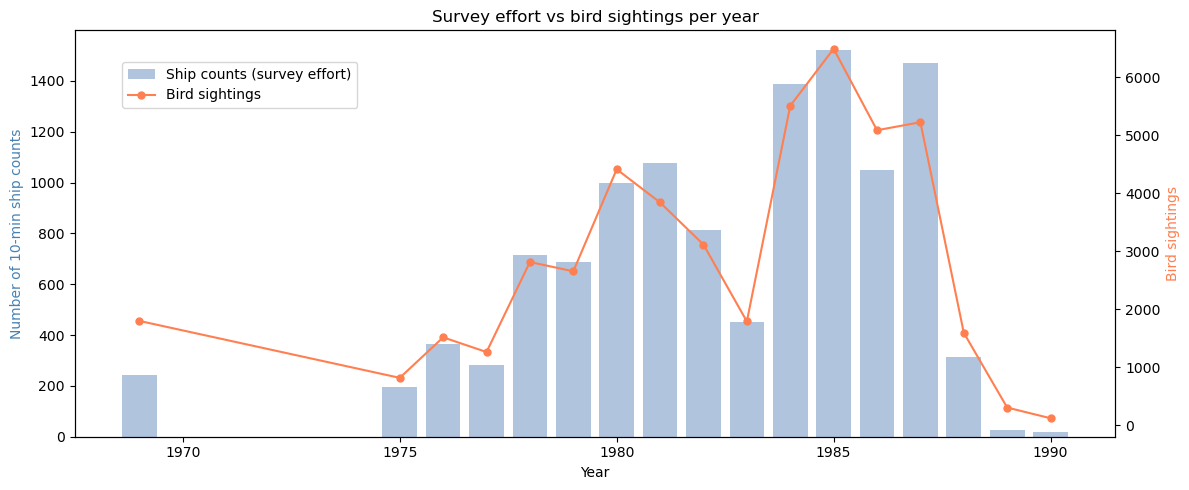

In [54]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(yearly["year"], yearly["n_ship_counts"], color="lightsteelblue", label="Ship counts (survey effort)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of 10-min ship counts", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(yearly["year"], yearly["n_sightings"], color="coral", marker="o", markersize=5, label="Bird sightings")
ax2.set_ylabel("Bird sightings", color="coral")

ax1.set_title("Survey effort vs bird sightings per year")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

# Bird Sightings at Sea: Analysis Report
### New Zealand Waters, 1969–1990 | Te Papa Tongarewa Dataset

---

## Dataset overview

- **49,019** bird observation records across **12,310** ten-minute ship counts
- **48,328** actual sightings (691 records marked "no birds seen")
- **321** unique common name entries mapping to **310** scientific species/aggregates
- Survey period: **July 1969 – December 1990** (21 years)
- Geography: Southern hemisphere, latitudes −19° to −69°, centred around New Zealand
  and subantarctic waters

---

## Phase 2: Data quality findings

The `species_common_name` field (free-text logbook entries) was parsed by Te Papa
staff into structured columns. The parsing was highly consistent:

- **Zero mismatches** between common name and scientific name — every common name
  maps to exactly one scientific name
- **Zero age mismatches** — every entry containing "AD", "JUV", "IMM", or "SUBAD"
  in the common name has the corresponding `age` column correctly populated (10,177
  entries verified)
- **Plumage phases** for Wandering albatross (PL1–PL5) are correctly split into
  `wan_plumage_phase`; the 1,735 NaN values in that column are correct — they
  correspond to age-coded entries (AD, SUBAD, JUV) which go to `age` instead
- **Sex** was almost never recorded in logbooks — only 4 entries have a sex value
  out of 48,328 sightings. This is a genuine data sparsity, not a parsing failure.

**Conclusion:** The structured columns faithfully represent the logbook entries.
The limitation is the logbooks themselves — observers focused on species and
plumage, rarely noting age beyond albatrosses, and almost never sex.

---

## Phase 3: Species and behaviour

**Top species by sighting frequency (base species):**

1. Wandering albatross — 11,293 sightings (23% of all records)
2. Black-browed albatross — 3,610
3. Cape petrel — 2,936
4. Grey-faced petrel — 2,597
5. Giant petrel — 2,168

The community is dominated by open-ocean pelagic species typical of subantarctic
and southern ocean waters.

**Behaviour breakdown:**
- 42.4% of sightings: birds following the ship's wake
- 42.0% of sightings: birds flying past
- 23.9%: accompanying (flying alongside)
- 12.9%: feeding (on ship discards)
- 3.5%: naturally feeding (not on discards)

Ships were ecological attractors — nearly half of all bird contacts involved
active ship-following behaviour. Only 3.5% of sightings captured birds feeding
independently of the vessel.

**Flock size:** Highly skewed — median of 2 birds per sighting, mean of ~29.
Half of all sightings (20,357) were of a single bird. Large aggregations (100+)
accounted for only 1,018 sightings.

---

## Phase 4: Environmental and ship activity effects

**Wind strength (Beaufort scale):**
Largest average flocks in calm conditions (class 0: 88 birds/sighting) and light
air (class 1: 67 birds/sighting) — birds raft on the water surface in still
conditions. A secondary peak at class 6–7 (strong breeze to near gale: ~27–29
birds/sighting) likely reflects albatrosses using strong winds for dynamic soaring
and concentrating in favourable updraft zones.

**Sea state:**
Average flock size drops consistently as seas roughen — from 59 birds/sighting
in calm/rippled conditions (class 1) to 6.7 in very rough seas (class 6). Rough
conditions make counting harder and disperse sitting birds.

**Ship activity — the strongest signal in the dataset:**

| Activity | Avg birds per sighting | % following ship |
|---|---|---|
| Trawling | **146** | 7% |
| Steaming | 29.6 | **27%** |
| Stationary | 15.4 | 0.5% |

Trawling attracts nearly **5× more birds** than ordinary sailing — driven by fish
waste and discards. Birds gather to feed rather than follow; hence the low
following rate despite the enormous flock sizes. When simply steaming, the ship
itself is the attractor — 27% of sightings involve birds actively following the
wake.

---

## Phase 5: Geography and seasonality

**Survey effort over time:**
Sightings were not uniformly distributed across the 21-year period. The main
survey era was 1980–1987, peaking at 6,487 sightings in 1985. The years 1969,
1975–1976 had isolated survey bursts. After 1987, effort declined sharply
(1,593 → 305 → 121 sightings). Any apparent trend in bird numbers over time
reflects survey effort, not population change.

**Species habitat preference:**
Australasian gannet was found in notably calmer waters (avg sea state 3.29) than
open-ocean species (3.74–3.83), consistent with its coastal distribution. All
other top species occupy similar moderate-rough sea conditions.

**Seasonal patterns:**
- **Wandering albatross** peaks strongly in spring (3,781 sightings vs ~2,300–2,800
  in other seasons), consistent with spring breeding returns to subantarctic islands
- **Cape petrel** and **Black-browed albatross** peak in spring and winter —
  winter-resident species in NZ waters
- **Grey-faced petrel** is the most seasonally consistent — a year-round presence

---

## Key takeaways

1. **Ships were wildlife attractors**, not neutral observers — trawling created
   feeding frenzies 5× larger than normal steaming conditions
2. **Wandering albatross dominated** every dimension of this dataset: most sightings,
   highest ship-following rate, most detailed recording (plumage phases)
3. **Data quality was excellent** — Te Papa's parsing of free-text logbook entries
   into structured columns was perfectly consistent
4. **Survey effort must be controlled for** in any temporal analysis — the decline
   after 1987 is an observer effect, not an ecological signal
5. **Spring was peak season** for most species, reflecting breeding cycles on
   nearby subantarctic islands

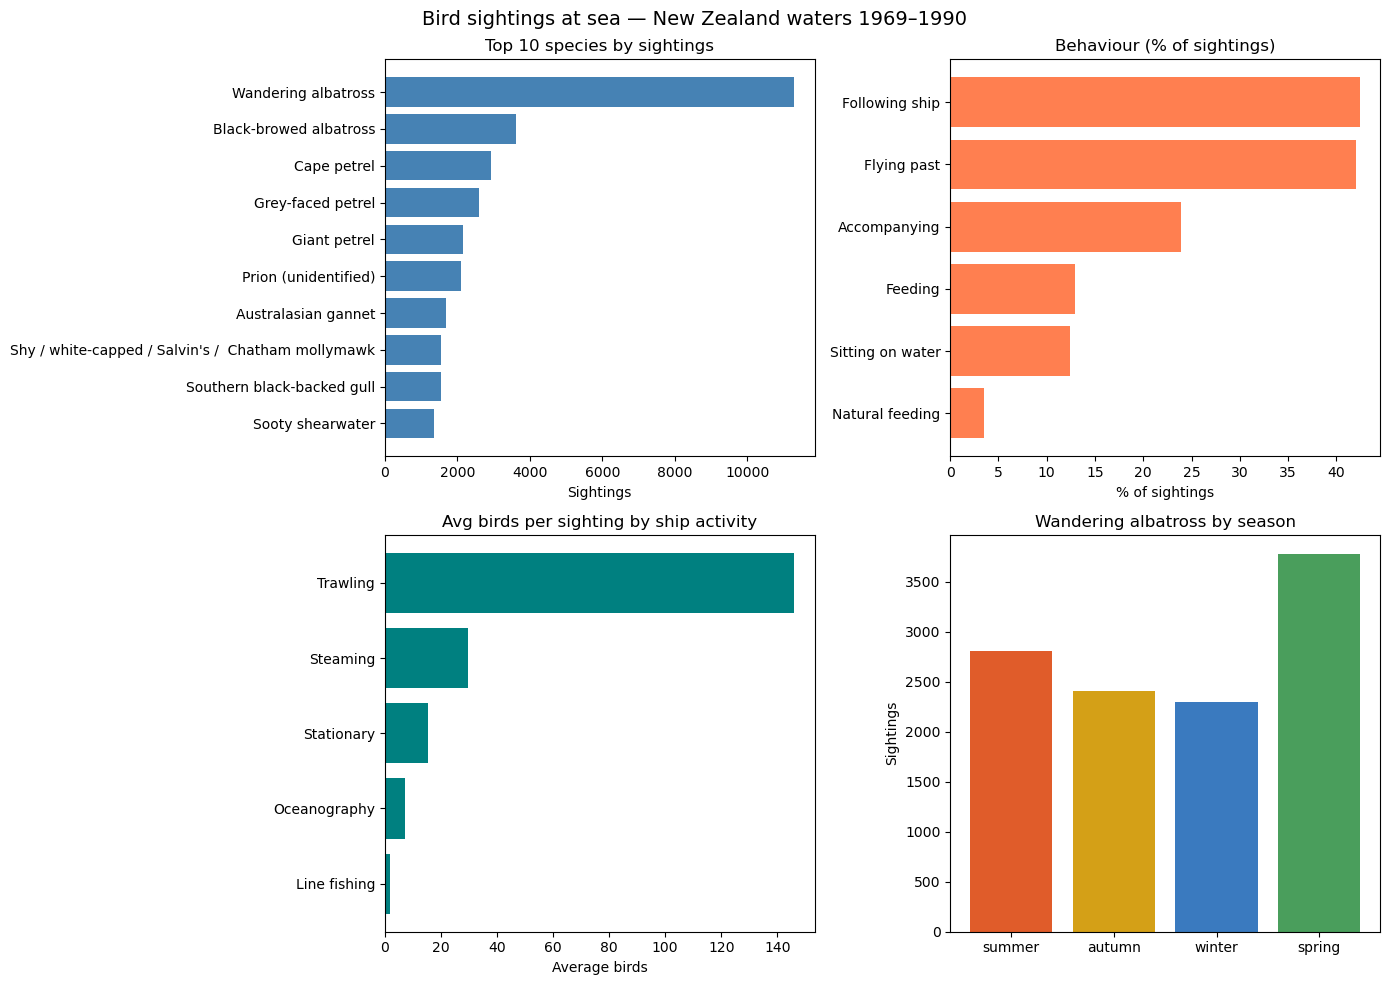

Summary figure saved.


In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bird sightings at sea — New Zealand waters 1969–1990", fontsize=14)

# Top-left: top 10 species
top10 = df["base_species"].value_counts().head(10).sort_values()
axes[0, 0].barh(top10.index, top10.values, color="steelblue")
axes[0, 0].set_title("Top 10 species by sightings")
axes[0, 0].set_xlabel("Sightings")

# Top-right: behaviour %
beh = pd.Series({
    "Following ship": 42.4, "Flying past": 42.0, "Accompanying": 23.9,
    "Feeding": 12.9, "Sitting on water": 12.4, "Natural feeding": 3.5
}).sort_values()
axes[0, 1].barh(beh.index, beh.values, color="coral")
axes[0, 1].set_title("Behaviour (% of sightings)")
axes[0, 1].set_xlabel("% of sightings")

# Bottom-left: avg birds by ship activity
act = pd.Series({
    "Trawling": 146, "Steaming": 29.6,
    "Stationary": 15.4, "Oceanography": 7.1, "Line fishing": 2.0
}).sort_values()
axes[1, 0].barh(act.index, act.values, color="teal")
axes[1, 0].set_title("Avg birds per sighting by ship activity")
axes[1, 0].set_xlabel("Average birds")

# Bottom-right: wandering albatross by season
wan_s = df[df["base_species"] == "Wandering albatross"]["season"].value_counts()
wan_s = wan_s.reindex(["summer", "autumn", "winter", "spring"])
colours = ["#e05c2a", "#d4a017", "#3a7abf", "#4a9e5c"]
axes[1, 1].bar(wan_s.index, wan_s.values, color=colours)
axes[1, 1].set_title("Wandering albatross by season")
axes[1, 1].set_ylabel("Sightings")

plt.tight_layout()
plt.savefig("bird_sightings_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Summary figure saved.")